💰 NBA TOTALS PREDICTION | PROFIT-OPTIMIZED MODEL
Today: 2025-12-24 01:50
TARGET: Maximize ROI after -110 vig
✅ Loaded profit-optimized data: 1,894 games
   File used: nba_modeling_profit.csv
   OVER rate: 52.7%

ENGINEERING BETTING-SPECIFIC FEATURES
✅ Created 11 betting-specific features:
HOME_PPG_10, AWAY_PPG_10, HOME_PACE_10, AWAY_PACE_10, LEAGUE_PACE_30D, LINE_VALUE, HOME_PACE_DIFF, AWAY_PACE_DIFF, HOME_MOMENTUM, AWAY_MOMENTUM, LATE_SEASON

SETTING UP TIME-SERIES VALIDATION
✅ Time-series splits created:
   Fold 1: Train 2021-11-15→2021-12-26 | Test 2021-12-30→2022-12-23
   Fold 2: Train 2021-11-15→2022-12-21 | Test 2022-12-23→2023-12-21
   Fold 3: Train 2021-11-15→2023-12-18 | Test 2023-12-21→2024-12-21
   Fold 4: Train 2021-11-15→2024-12-19 | Test 2024-12-21→2025-12-23

SETTING UP BETTING-SPECIFIC OPTIMIZATION
✅ Custom ROI metric function created (XGBoost 1.6+ compatible)
   Confidence threshold: 55%
   Odds assumption: -110 (standard sportsbook)

TRAINING PROFIT-OPTIMIZED MODEL

🔄

<Figure size 1200x800 with 0 Axes>

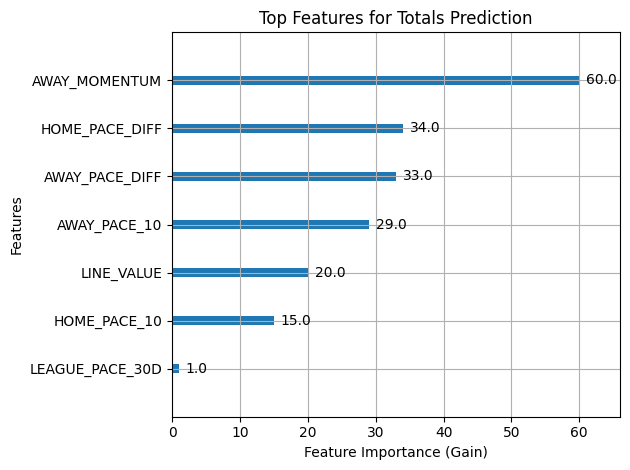

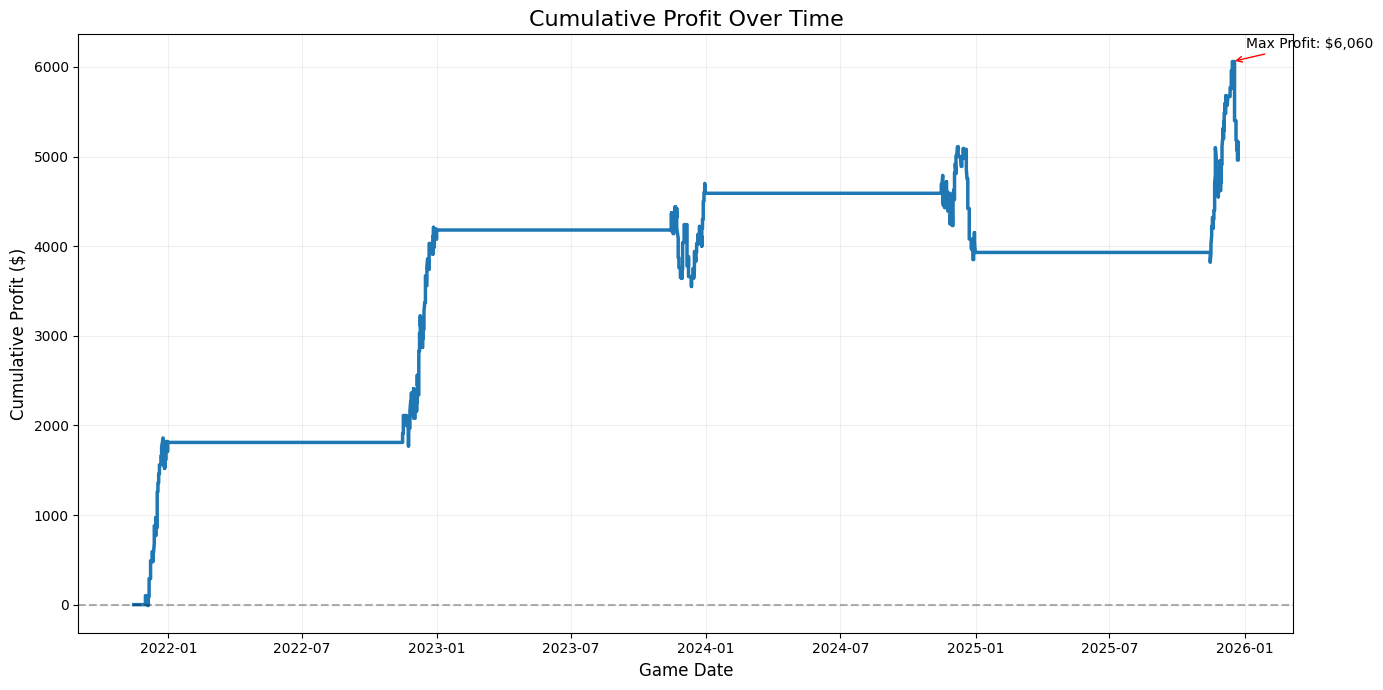

In [1]:
# 3_train_profit_model.py
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, roc_auc_score

# ========================================
# 📁 SETUP
# ========================================
DATA_DIR = 'data'
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"{'='*60}")
print(f"💰 NBA TOTALS PREDICTION | PROFIT-OPTIMIZED MODEL")
print(f"Today: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"TARGET: Maximize ROI after -110 vig")
print(f"{'='*60}")

# ========================================
# 🔍 STEP 1: LOAD OPTIMIZED DATASET
# ========================================
profit_filename = "nba_modeling_profit.csv"
data_path = os.path.join(DATA_DIR, profit_filename)

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Required dataset not found: {data_path}\n"
        f"Make sure your pipeline saves the file with this exact name."
    )

df = pd.read_csv(data_path)
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])

print(f"✅ Loaded profit-optimized data: {len(df):,} games")
print(f"   File used: {profit_filename}")
print(f"   OVER rate: {df['TARGET_OVER'].mean():.1%}")

# ========================================
# 📊 STEP 2: FEATURE ENGINEERING (BETTING-SPECIFIC)
# ========================================
print(f"\n{'='*50}")
print("ENGINEERING BETTING-SPECIFIC FEATURES")
print(f"{'='*50}")

# Feature 1: Line value (how far line is from neutral)
df['LINE_VALUE'] = (df['SIMULATED_LINE'] - 220).abs()  # 220 = historical median

# Feature 2: Pace differential (team pace vs league)
df['HOME_PACE_DIFF'] = df['HOME_PACE_10'] - df['LEAGUE_PACE_30D']
df['AWAY_PACE_DIFF'] = df['AWAY_PACE_10'] - df['LEAGUE_PACE_30D']

# Feature 3: Scoring momentum (recent trend)
df['HOME_MOMENTUM'] = df.groupby('HOME_TEAM')['HOME_PPG_10'].diff().fillna(0)
df['AWAY_MOMENTUM'] = df.groupby('AWAY_TEAM')['AWAY_PPG_10'].diff().fillna(0)

# Feature 4: Game importance proxy
df['GAME_NUMBER'] = df.groupby(['HOME_TEAM', df['GAME_DATE'].dt.year]).cumcount() + 1
df['LATE_SEASON'] = (df['GAME_NUMBER'] > 60).astype(int)  # Last 22 games

# Final feature set
FEATURES = [
    'HOME_PPG_10', 'AWAY_PPG_10',
    'HOME_PACE_10', 'AWAY_PACE_10',
    'LEAGUE_PACE_30D',
    'LINE_VALUE',
    'HOME_PACE_DIFF', 'AWAY_PACE_DIFF',
    'HOME_MOMENTUM', 'AWAY_MOMENTUM',
    'LATE_SEASON'
]
TARGET = 'TARGET_OVER'

print(f"✅ Created {len(FEATURES)} betting-specific features:")
print(", ".join(FEATURES))

# ========================================
# ⚖️ STEP 3: TIME-SERIES SPLIT (NO FUTURE DATA)
# ========================================
print(f"\n{'='*50}")
print("SETTING UP TIME-SERIES VALIDATION")
print(f"{'='*50}")

# Sort by date (critical for time-series)
df = df.sort_values('GAME_DATE').reset_index(drop=True)

# Create time-based splits (each fold = 1 season)
tscv = TimeSeriesSplit(n_splits=4, gap=30)  # 30-day gap between train/validation

# Prepare data
X = df[FEATURES]
y = df[TARGET]
dates = df['GAME_DATE']

print(f"✅ Time-series splits created:")
for i, (train_index, test_index) in enumerate(tscv.split(X)):
    train_dates = dates.iloc[train_index]
    test_dates = dates.iloc[test_index]
    print(f"   Fold {i+1}: Train {train_dates.min().date()}→{train_dates.max().date()} | "
          f"Test {test_dates.min().date()}→{test_dates.max().date()}")

# ========================================
# 🎯 STEP 4: CUSTOM BETTING OBJECTIVE FUNCTION
# ========================================
print(f"\n{'='*50}")
print("SETTING UP BETTING-SPECIFIC OPTIMIZATION")
print(f"{'='*50}")

# Updated: Proper custom metric function for XGBoost 1.6+
def roi_metric(preds: np.ndarray, dtrain: xgb.DMatrix) -> tuple:
    """
    Custom ROI metric for -110 odds betting
    Returns tuple of (metric_name, metric_value)
    """
    labels = dtrain.get_label()
    confidence_threshold = 0.55
    
    # Calculate which games we would bet on
    bets = preds > confidence_threshold
    
    # Calculate wins and losses
    wins = bets & (labels == 1)
    losses = bets & (labels == 0)
    
    # -110 odds: Win $100 for every $110 bet
    profit = (wins * 100) - (losses * 110)
    total_staked = bets.sum() * 110
    
    # Calculate ROI percentage
    if total_staked == 0:
        roi = 0.0
    else:
        roi = (profit.sum() / total_staked) * 100
    
    return 'roi', roi

# XGBoost parameters optimized for betting ROI
params = {
    'objective': 'binary:logistic',
    'disable_default_eval_metric': 1,  # Critical: disable default metrics
    'max_depth': 5,               # Prevent overfitting
    'learning_rate': 0.05,        # Conservative learning
    'subsample': 0.8,             # Random feature selection
    'colsample_bytree': 0.8,      # Random tree selection
    'min_child_weight': 10,       # Require sufficient evidence
    'scale_pos_weight': 1.0,      # Balanced classes
    'seed': 42,
    'tree_method': 'hist'         # Faster training
}

print(f"✅ Custom ROI metric function created (XGBoost 1.6+ compatible)")
print(f"   Confidence threshold: 55%")
print(f"   Odds assumption: -110 (standard sportsbook)")

# ========================================
# 🧪 STEP 5: TRAIN WITH TIME-SERIES VALIDATION
# ========================================
print(f"\n{'='*50}")
print("TRAINING PROFIT-OPTIMIZED MODEL")
print(f"{'='*50}")

best_model = None
best_roi = -np.inf
results = []

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"\n🔄 Fold {fold+1}/4")
    
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Create DMatrices
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    
    # Train model with proper custom metric
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=500,
        evals=[(dtrain, 'train'), (dtest, 'test')],
        custom_metric=roi_metric,  # Use the properly defined metric function
        early_stopping_rounds=50,
        verbose_eval=50
    )
    
    # Evaluate
    preds = model.predict(dtest)
    test_roi = roi_metric(preds, xgb.DMatrix(X_test, label=y_test))[1]
    test_acc = accuracy_score(y_test, (preds > 0.5).astype(int))
    test_auc = roc_auc_score(y_test, preds)
    
    print(f"✅ Fold {fold+1} Results:")
    print(f"   ROI: {test_roi:.2f}% | Accuracy: {test_acc:.1%} | AUC: {test_auc:.3f}")
    
    results.append({
        'fold': fold+1,
        'roi': test_roi,
        'accuracy': test_acc,
        'auc': test_auc,
        'best_iteration': model.best_iteration
    })
    
    # Track best model by ROI
    if test_roi > best_roi:
        best_roi = test_roi
        best_model = model
        print(f"   🏆 New best ROI model saved")

print(f"\n{'='*50}")
print(f"✅ TRAINING COMPLETE | BEST ROI: {best_roi:.2f}%")
print(f"{'='*50}")

# ========================================
# 📈 STEP 6: MODEL ANALYSIS & SAVING
# ========================================

# Feature importance
plt.figure(figsize=(12, 8))
xgb.plot_importance(
    best_model, 
    max_num_features=10,
    title='Top Features for Totals Prediction',
    xlabel='Feature Importance (Gain)'
)
plt.tight_layout()
feature_path = os.path.join(MODEL_DIR, 'feature_importance.png')
plt.savefig(feature_path)
print(f"✅ Feature importance saved: {feature_path}")

# ----------------------------------------
# ✅ SAVE MODEL (STATIC NAME – OVERWRITES)
# ----------------------------------------
model_path = os.path.join(MODEL_DIR, 'profit_model.json')
best_model.save_model(model_path)
print(f"✅ Model saved (overwritten if exists): {model_path}")

# ----------------------------------------
# ✅ SAVE TRAINING RESULTS (STATIC NAME)
# ----------------------------------------
results_path = os.path.join(MODEL_DIR, 'training_results.json')
with open(results_path, 'w') as f:
    json.dump({
        'training_date': datetime.now().isoformat(),
        'best_roi': best_roi,
        'folds': results,
        'parameters': params,
        'features': FEATURES,
        'confidence_threshold': 0.55,
        'odds_assumption': -110
    }, f, indent=2)

print(f"✅ Training results saved (overwritten if exists): {results_path}")


# ========================================
# 💰 STEP 7: BACKTESTING SIMULATION
# ========================================
print(f"\n{'='*50}")
print("RUNNING REALISTIC BACKTEST")
print(f"{'='*50}")

# Get all predictions
dall = xgb.DMatrix(X)
all_preds = best_model.predict(dall)

# Simulate betting strategy
df['PRED_PROB'] = all_preds
confidence_threshold = 0.55  # Same as in metric function
df['BET_OVER'] = (df['PRED_PROB'] > confidence_threshold).astype(int)  # Only bet when >55% confident
df['BET_AMOUNT'] = np.where(df['BET_OVER'] == 1, 110, 0)  # $110 bets at -110 odds

# Calculate profit
df['WIN'] = np.where((df['BET_OVER'] == 1) & (df['TARGET_OVER'] == 1), 100, 0)
df['LOSS'] = np.where((df['BET_OVER'] == 1) & (df['TARGET_OVER'] == 0), -110, 0)
df['PROFIT'] = df['WIN'] + df['LOSS']

# Aggregate results
total_bet = df['BET_AMOUNT'].sum()
total_profit = df['PROFIT'].sum()
roi = (total_profit / total_bet) * 100 if total_bet > 0 else 0
bet_rate = df['BET_OVER'].mean()
confidence_games = df['BET_OVER'] == 1
if confidence_games.any():
    accuracy = accuracy_score(
        df.loc[confidence_games, 'TARGET_OVER'],
        (df.loc[confidence_games, 'PRED_PROB'] > 0.5).astype(int)
    )
else:
    accuracy = 0.0

print(f"\n{'='*50}")
print(f"📊 BACKTEST RESULTS (REALISTIC -110 ODDS)")
print(f"{'='*50}")
print(f"   Games analyzed: {len(df):,}")
print(f"   Games bet on: {df['BET_OVER'].sum():,} ({bet_rate:.1%})")
print(f"   Betting accuracy: {accuracy:.1%}")
print(f"   Total bet: ${total_bet:,.0f}")
print(f"   Total profit: ${total_profit:,.0f}")
print(f"   ROI: {roi:.2f}%")
print(f"   Profit factor: {total_profit/total_bet:.3f} (1.0 = break even)")

# Plot profit curve
plt.figure(figsize=(14, 7))
profit_curve = df.sort_values('GAME_DATE')['PROFIT'].cumsum()
plt.plot(df.sort_values('GAME_DATE')['GAME_DATE'], profit_curve, 
         linewidth=2.5, color='#1f77b4')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('Cumulative Profit Over Time', fontsize=16)
plt.xlabel('Game Date', fontsize=12)
plt.ylabel('Cumulative Profit ($)', fontsize=12)
plt.grid(alpha=0.2)

# Add annotations
max_profit = profit_curve.max()
max_date = df.sort_values('GAME_DATE').iloc[profit_curve.idxmax()]['GAME_DATE']
plt.annotate(f'Max Profit: ${max_profit:,.0f}', 
            xy=(max_date, max_profit),
            xytext=(10, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'))

profit_path = os.path.join(MODEL_DIR, 'profit_curve.png')
plt.tight_layout()
plt.savefig(profit_path)
print(f"✅ Profit curve saved: {profit_path}")

print(f"\n{'='*50}")
print(f"🎯 STATIC MODEL READY FOR LIVE BETTING")
print(f"{'='*50}")
print(f"Next step: Build LIVE model with API-Basketball.com integration")
print(f"   → Will predict during games using real-time stats")
print(f"   → Combines with static model for ultimate edge")